This notebook compares the scores between AIDE and the true scores

---
This cell shows the average score given by the evaluator.

AIDE scores
  Students: 39
  Mean: 55.87
  Std dev: 12.19

True scores
  Students: 39
  Mean: 87.87
  Std dev: 7.58

Students evaluated (with true scores): 39


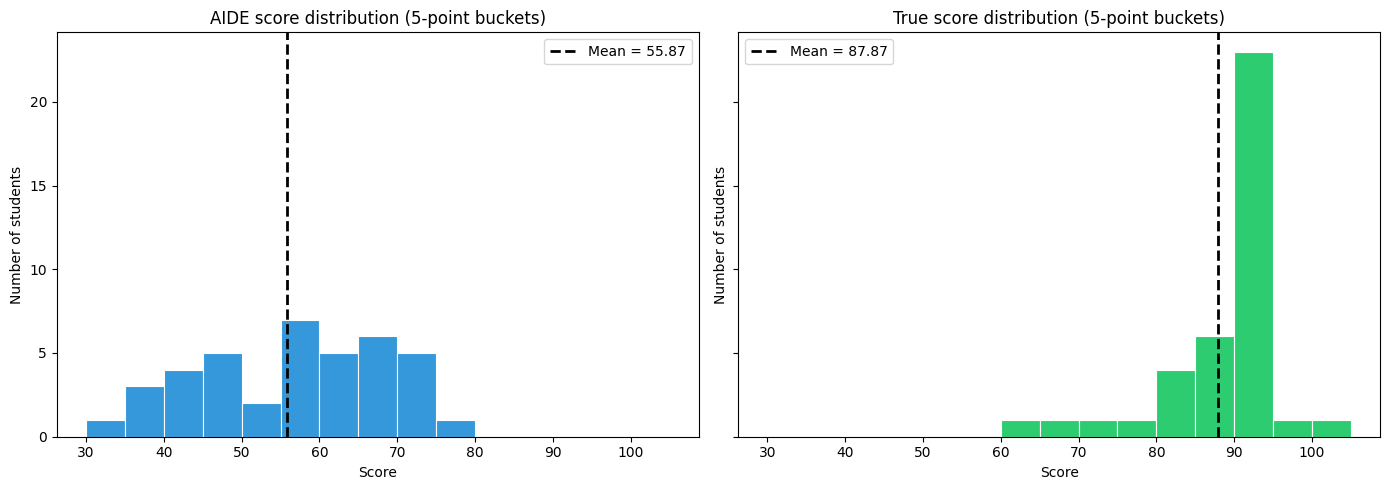

In [9]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

AIDE_ROOT = Path("aide")
BIN_WIDTH = 5

true_scores = pd.read_csv(AIDE_ROOT / "student-responses/gsu-student-sumprod-video-list.csv")
evaluation_scores = pd.read_csv(AIDE_ROOT / "out/results/class_results.csv")

true_scores["alias"] = true_scores["email"].str.split("@").str[0]
comparison = true_scores.merge(evaluation_scores, on="alias", how="inner")

aide_scores = comparison["score"]
true_scores_eval = comparison["true_score"]

n_students = len(comparison)

def print_stats(label, scores):
    print(f"{label}")
    print(f"  Students: {len(scores)}")
    print(f"  Mean: {scores.mean():.2f}")
    print(f"  Std dev: {scores.std():.2f}")

print_stats("AIDE scores", aide_scores)
print()
print_stats("True scores", true_scores_eval)

all_scores = pd.concat([aide_scores, true_scores_eval])
bin_min = BIN_WIDTH * np.floor(all_scores.min() / BIN_WIDTH)
bin_max = BIN_WIDTH * np.ceil(all_scores.max() / BIN_WIDTH) + BIN_WIDTH
bins = np.arange(bin_min, bin_max, BIN_WIDTH)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, scores, color, title in [
    (axes[0], aide_scores, "#3498db", "AIDE"),
    (axes[1], true_scores_eval, "#2ecc71", "True"),
]:
    mean = scores.mean()
    ax.hist(scores, bins=bins, color=color, edgecolor="white", linewidth=0.8)
    ax.axvline(mean, color="black", linestyle="--", linewidth=2, label=f"Mean = {mean:.2f}")
    ax.set_xlabel("Score")
    ax.set_ylabel("Number of students")
    ax.set_title(f"{title} score distribution ({BIN_WIDTH}-point buckets)")
    ax.legend()

print(f"\nStudents evaluated (with true scores): {n_students}")
plt.tight_layout()
plt.show()

---
This cell shows the per-student difference between the AIDE-generated score and the true score they received in the class.

/var/folders/s7/0by0bnjx63vb30z3zkv7rbsw0000gn/T/ipykernel_700/2745574361.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


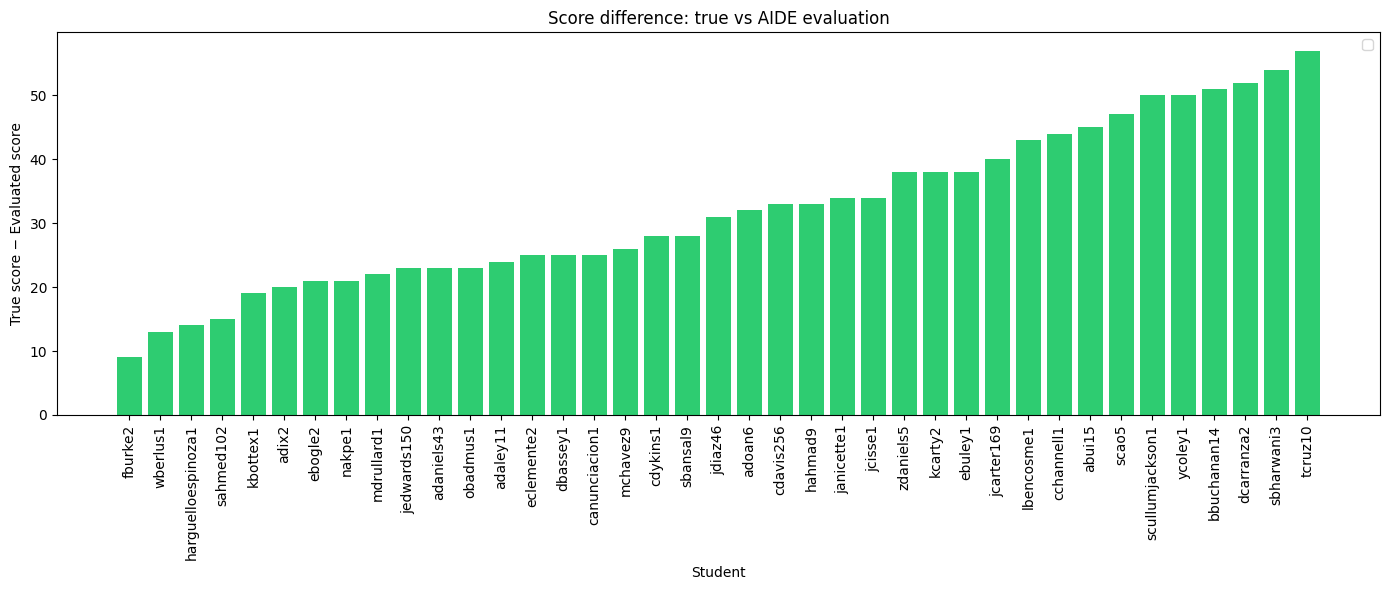

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

AIDE_ROOT = Path("aide")

true_scores = pd.read_csv(AIDE_ROOT / "student-responses/gsu-student-sumprod-video-list.csv")
evaluation_scores = pd.read_csv(AIDE_ROOT / "out/results/class_results.csv")

true_scores["alias"] = true_scores["email"].str.split("@").str[0]

comparison = true_scores.merge(evaluation_scores, on="alias", how="inner")
comparison["delta"] = comparison["true_score"] - comparison["score"]
comparison = comparison.sort_values("delta")

mean_delta = comparison["delta"].mean()

fig, ax = plt.subplots(figsize=(14, 6))
colors = ["#2ecc71" if d >= 0 else "#e74c3c" for d in comparison["delta"]]
ax.bar(comparison["alias"], comparison["delta"], color=colors)
# ax.axhline(0, color="gray", linewidth=0.8)
# ax.axhline(
#     mean_delta,
#     color="black",
#     linestyle="--",
#     linewidth=2,
#     label=f"Mean = {mean_delta:.2f}",
# )
ax.set_xlabel("Student")
ax.set_ylabel("True score − Evaluated score")
ax.set_title("Score difference: true vs AIDE evaluation")
ax.legend()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# comparison[["alias", "true_score", "score", "delta"]]

---

This cell shows a histogram of how the error in scoring is distributed.

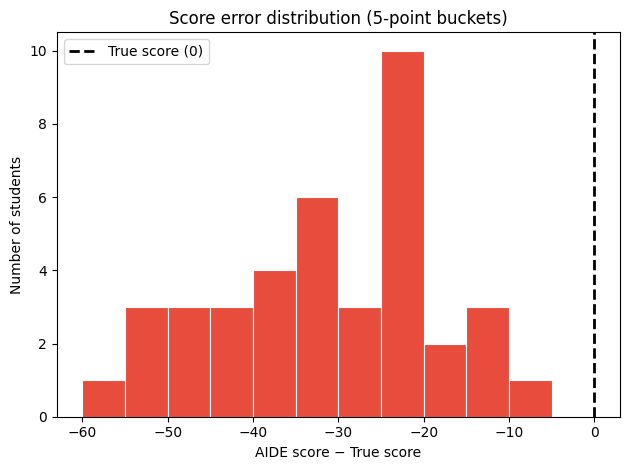

In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

AIDE_ROOT = Path("aide")
BIN_WIDTH = 5

true_scores = pd.read_csv(AIDE_ROOT / "student-responses/gsu-student-sumprod-video-list.csv")
evaluation_scores = pd.read_csv(AIDE_ROOT / "out/results/class_results.csv")

true_scores["alias"] = true_scores["email"].str.split("@").str[0]
comparison = true_scores.merge(evaluation_scores, on="alias", how="inner")

# Eval relative to true: 0 = match, negative = eval lower, positive = eval higher
comparison["error"] = comparison["score"] - comparison["true_score"]

bin_min = BIN_WIDTH * np.floor(comparison["error"].min() / BIN_WIDTH)
bin_max = BIN_WIDTH * np.ceil(comparison["error"].max() / BIN_WIDTH) + BIN_WIDTH
bins = np.arange(bin_min, bin_max, BIN_WIDTH)

counts, edges, patches = plt.hist(
    comparison["error"],
    bins=bins,
    edgecolor="white",
    linewidth=0.8,
)
for patch, left in zip(patches, edges[:-1]):
    patch.set_facecolor("#e74c3c" if left < 0 else "#2ecc71" if left >= 0 else "#95a5a6")

plt.axvline(0, color="black", linestyle="--", linewidth=2, label="True score (0)")
plt.xlabel("AIDE score − True score")
plt.ylabel("Number of students")
plt.title(f"Score error distribution ({BIN_WIDTH}-point buckets)")
plt.legend()
plt.tight_layout()
plt.show()

---
This cell shows the number of undetermined criteria per rubric category

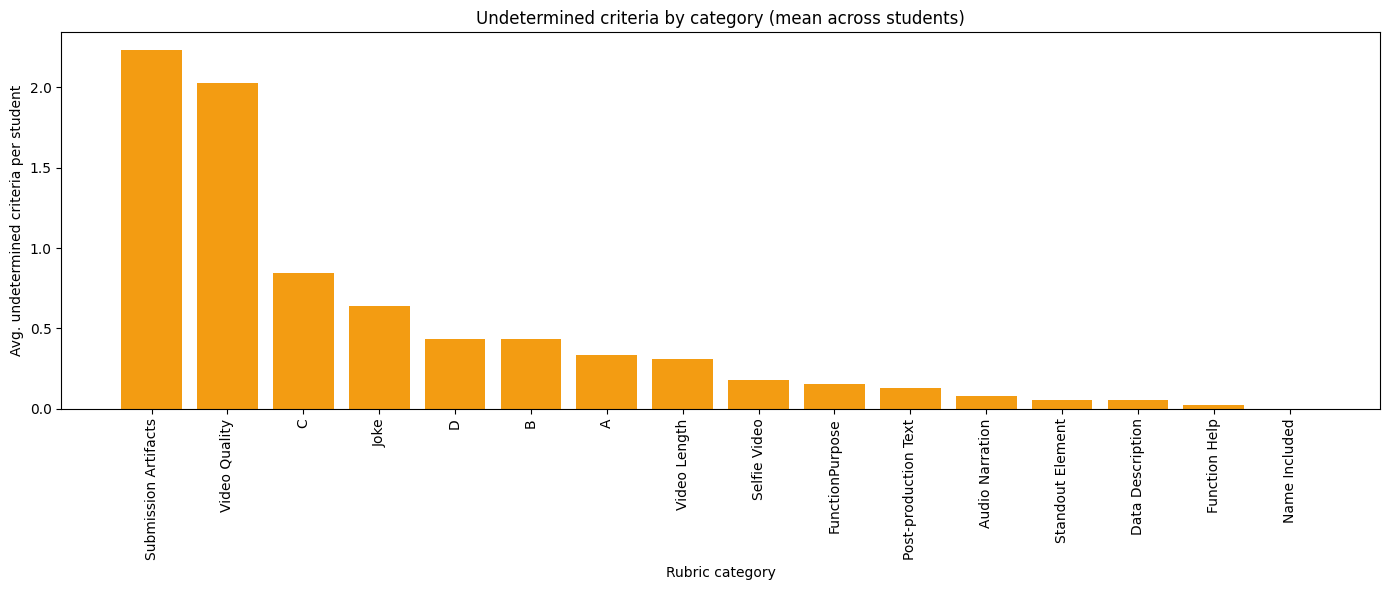

In [7]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd

AIDE_ROOT = Path("aide")
RESULTS_DIR = AIDE_ROOT / "out/results"

rows = []
for result_file in sorted(RESULTS_DIR.glob("*.json")):
    alias = result_file.stem
    with open(result_file) as f:
        categories = json.load(f)
    for cat in categories:
        undetermined = sum(
            1 for leaf in cat["leaf_results"] if leaf.get("verdict") == "undetermined"
        )
        rows.append(
            {"alias": alias, "category": cat["category"], "undetermined": undetermined}
        )

per_student = pd.DataFrame(rows)
avg_by_category = (
    per_student.groupby("category", as_index=False)["undetermined"]
    .mean()
    .rename(columns={"undetermined": "avg_undetermined"})
    .sort_values("avg_undetermined", ascending=False)
)

# print(f"Students evaluated: {per_student['alias'].nunique()}")
# avg_by_category

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(
    avg_by_category["category"],
    avg_by_category["avg_undetermined"],
    color="#f39c12",
)
ax.set_xlabel("Rubric category")
ax.set_ylabel("Avg. undetermined criteria per student")
ax.set_title("Undetermined criteria by category (mean across students)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()